## Iris - exploratory data analysis

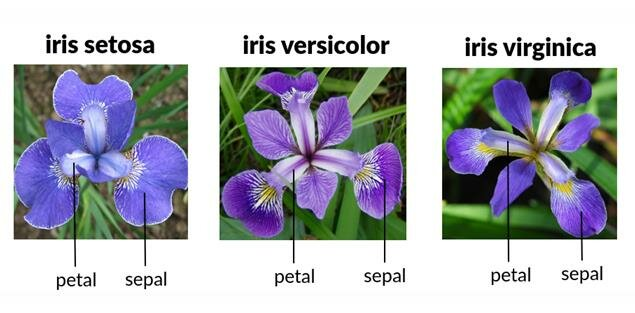

Iris dataset is one of the most classical in data science (Fisher 1936). It contains 150 measurements of flowers belonging to the three species: 
- Iris setosa, 
- Iris versicolor,
- Iris virginica.
 
There are four features measured: 
- sepal length,
- sepal width,
- petal length,
- petal width.

Each class contains 50 samples so the dataset is balanced. There are no missing values.
The dataset is available at https://archive.ics.uci.edu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# set the path to the raw dataset according to your case
dataset_path = "iris.data"

df = pd.read_csv(
    dataset_path,
    header=None,
    names=["sepal_length", "sepal_width", "petal_length", "petal_width", "class"])

df["class"] = df["class"].astype("category")
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.groupby("class").describe().T

class               Iris-setosa  Iris-versicolor  Iris-virginica
sepal_length count    50.000000        50.000000       50.000000
             mean      5.006000         5.936000        6.588000
             std       0.352490         0.516171        0.635880
             min       4.300000         4.900000        4.900000
             25%       4.800000         5.600000        6.225000
             50%       5.000000         5.900000        6.500000
             75%       5.200000         6.300000        6.900000
             max       5.800000         7.000000        7.900000
sepal_width  count    50.000000        50.000000       50.000000
             mean      3.418000         2.770000        2.974000
             std       0.381024         0.313798        0.322497
             min       2.300000         2.000000        2.200000
             25%       3.125000         2.525000        2.800000
             50%       3.400000         2.800000        3.000000
             75%       3.675000         3.000000        3.175000
             max       4.400000         3.400000        3.800000
petal_length count    50.000000        50.000000       50.000000
             mean      1.464000         4.260000        5.552000
             std       0.173511         0.469911        0.551895
             min       1.000000         3.000000        4.500000
             25%       1.400000         4.000000        5.100000
             50%       1.500000         4.350000        5.550000
             75%       1.575000         4.600000        5.875000
             max       1.900000         5.100000        6.900000
petal_width  count    50.000000        50.000000       50.000000
             mean      0.244000         1.326000        2.026000
             std       0.107210         0.197753        0.274650
             min       0.100000         1.000000        1.400000
             25%       0.200000         1.200000        1.800000
             50%       0.200000         1.300000        2.000000
             75%       0.300000         1.500000        2.300000
             max       0.600000         1.800000        2.500000

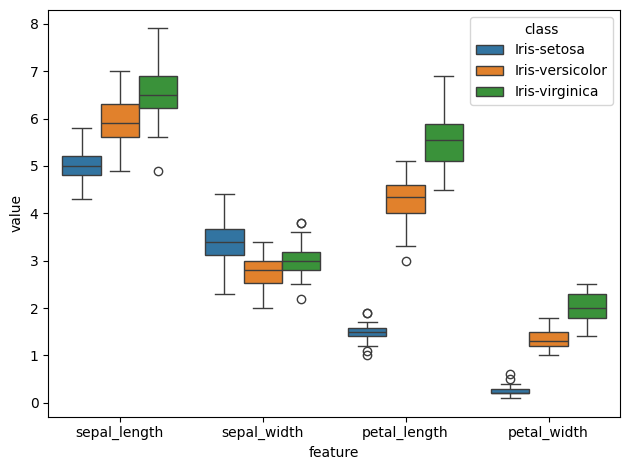

In [4]:
df_long = df.melt(id_vars="class", var_name="feature", value_name="value")
sns.boxplot(data=df_long, x="feature", y="value", hue="class")
plt.tight_layout()
plt.show()

Petal length, petal width and sepal length are very distinctive for each class. 

Sepal width alone doesn't tell much about the class.

In [5]:
df.groupby("class").corr()

sepal_length  sepal_width  petal_length  \
class                                                                   
Iris-setosa     sepal_length      1.000000     0.746780      0.263874   
                sepal_width       0.746780     1.000000      0.176695   
                petal_length      0.263874     0.176695      1.000000   
                petal_width       0.279092     0.279973      0.306308   
Iris-versicolor sepal_length      1.000000     0.525911      0.754049   
                sepal_width       0.525911     1.000000      0.560522   
                petal_length      0.754049     0.560522      1.000000   
                petal_width       0.546461     0.663999      0.786668   
Iris-virginica  sepal_length      1.000000     0.457228      0.864225   
                sepal_width       0.457228     1.000000      0.401045   
                petal_length      0.864225     0.401045      1.000000   
                petal_width       0.281108     0.537728      0.322108   

                              petal_width  
class                                      
Iris-setosa     sepal_length     0.279092  
                sepal_width      0.279973  
                petal_length     0.306308  
                petal_width      1.000000  
Iris-versicolor sepal_length     0.546461  
                sepal_width      0.663999  
                petal_length     0.786668  
                petal_width      1.000000  
Iris-virginica  sepal_length     0.281108  
                sepal_width      0.537728  
                petal_length     0.322108  
                petal_width      1.000000

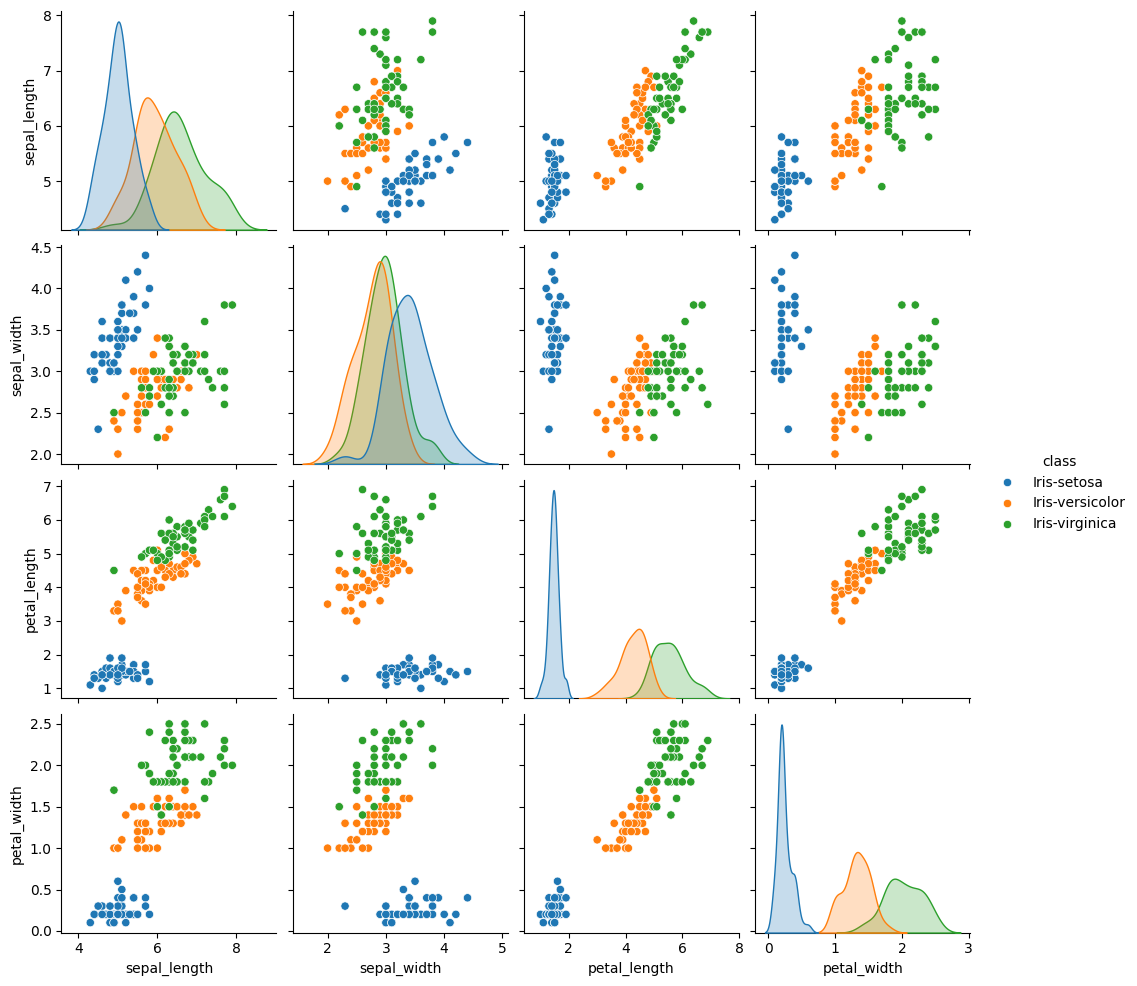

In [6]:
sns.pairplot(df, hue="class")
plt.show()

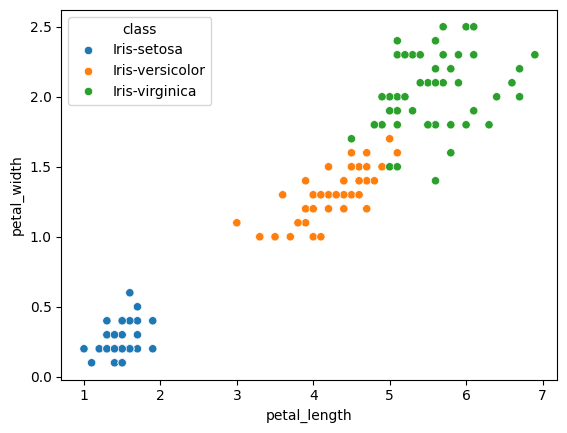

In [7]:
sns.scatterplot(data=df, x="petal_length", y="petal_width", hue="class")
plt.show()

'Iris setosa' can be separated very easily from the other two classes by a boundary petal_length = 2.45

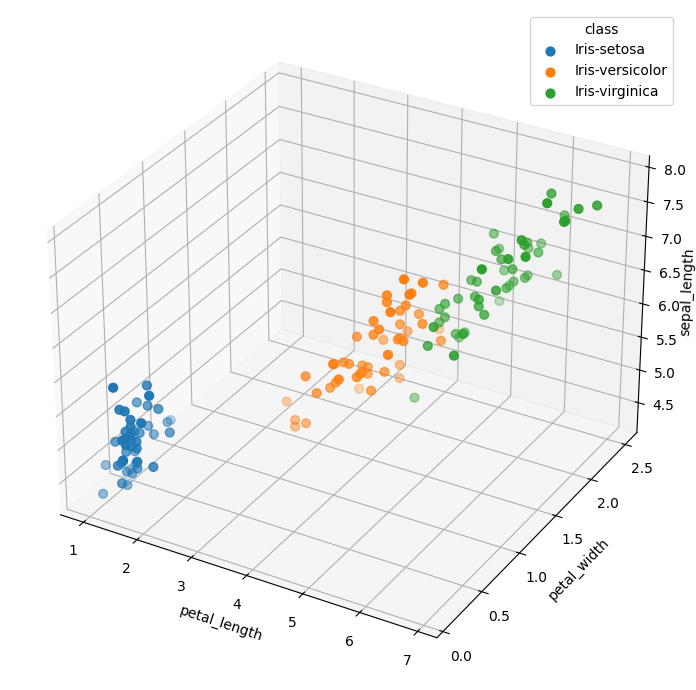

In [8]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")

for cls in df["class"].unique():
    subset = df[df["class"] == cls]
    ax.scatter(
        subset["petal_length"],
        subset["petal_width"],
        subset["sepal_length"],
        label=cls,
        s=40,
    )

ax.set_xlabel("petal_length")
ax.set_ylabel("petal_width")
ax.set_zlabel("sepal_length", labelpad=-1.5)
ax.legend(title="class")
plt.tight_layout()
plt.show()